In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

PHASE 1 : COLLECTE ET EXPLORATION


In [2]:
data=pd.read_csv(r"C:\Users\HP\OneDrive\Projet_Data\Projet 2\Fashion_sales.csv")
data

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3495,Allen Williams,T-Shirts,Oversized T-shirt,NaN,848.79,NaN,0.00,NaN,Mumbai,NaN,2259.00
2496,3496,Jonathan Hill,Shoes,Loafers,4.0,NaN,NaN,0.00,2024-03-10,Hyderabad,B2B,2232.98
2497,3497,Alejandro Cochran,Jackets,Bomber Jacket,NaN,3389.24,1.06,0.00,NaN,Ahmedabad,B2C,1955.31
2498,3498,Angela Adkins,Jeans,Straight Cut,5.0,3844.19,NaN,0.00,24-07-2024,Hyd,NaN,2967.00


In [3]:
data.dtypes

Order_ID              int64
Customer_Name        object
Product_Category     object
Product_Name         object
Units_Sold          float64
Unit_Price          float64
Discount_%          float64
Sales_Amount        float64
Order_Date           object
City                 object
Segment              object
Profit              float64
dtype: object

In [4]:
data.isnull().sum()

Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
Order_Date           606
City                   0
Segment              821
Profit                 0
dtype: int64

Notre dataset est un dataset qui porte sur des commandes commerciales. Nous pouvons observer qu'il contient 2500 commandes (lignes) et que ces dernières sont établies sur la base 12 caractéristiques (colonnes).
Notre dataset est constitué à 50% de variables numériques (Units_Sold , Unit_Price , Discount_% , Sales_Amount , Order_ID , Profit) et 50% de variable catégorielles ( Customer_Name , Product_Category, Product_Name , Order_Date , City , Segment). 
On observe des valeurs manquantes d'une assez grande quantité qui se rapproche de la moitié de la quantité de nos données pour Units_Sold , Unit_Price , Discount_%, Order_Date et Segment.

Pour vérifier la distribution de notre variable cible Profit , nous allons procéder par l'analyse des statistiques descriptives de cette dernière et nous allons la visualiser grâce à un histogramme.
Comme notre variable est une variable quantitative continue , les statistiques que nous allons analyser sont : la moyenne , la médiane , l'écart type et l'intervalle interquartile (IQR), le kurtosis et le skewness.
Pour la visualiser , nous allons utiliser un histogramme car c'est le graphique majoritairement utilisé pour regarder la distribution d'une variable.(phase 2)

In [5]:
#Statistiques descriptives
print("Voici les statistiques descriptives de base :")
print(data["Profit"].describe())
print("-------------------------------------------------------------------")
print("Le skewness est :", data["Profit"].skew())
print("Le kurtosis est :" ,data["Profit"].kurtosis())

Voici les statistiques descriptives de base :
count    2500.000000
mean      981.569032
std      1159.159244
min      -992.610000
25%       -19.670000
50%       947.885000
75%      1993.515000
max      2997.110000
Name: Profit, dtype: float64
-------------------------------------------------------------------
Le skewness est : 0.027370407805566637
Le kurtosis est : -1.1896983735278475


-Notre moyenne est de 981.57 , elle represente la valeur autour de laquelle les données de la variable "Profit" gravite.

-Notre écart-type ici est de 1159.16 , il représente le nombre par lequel nos données s'éloignent de la moyenne donc on peut dire que la plupart des profits se situent entre -178 et 2140.

-Notre mediane est de 947.86 , cela signifie que la valeur centrale du profit de notre distribution est 947.86 . L'IQR qui est la différence entre le 3e quartile et le premier ( 75% et 25%) est égale aussi à 947.86  , ce qui signifie que dans la zone des 50% centraux de notre distribution du profit est aussi égale à 947.86.

-Le skewness est supérieur légèrement supérieur à 0 , notre distribution est donc un peu asymétrique vers la droite .

-Le kurtosis est inférieur à 3 , notre distribution est donc applatie.

PHASE 2 : VISUALISATION

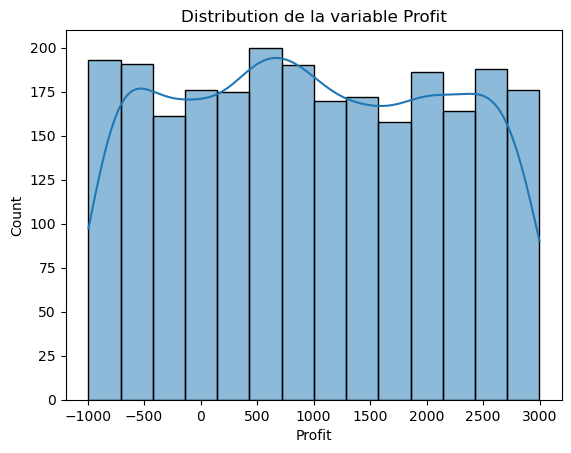

In [6]:
#Histogramme
sn.histplot(data["Profit"] , kde=True )
plt.title("Distribution de la variable Profit")
plt.show()

Notre graphique appuie les réponses apportées par les statistiques descriptives.

Ici , le graphique montre clairement une asymétrie légère au niveau des pâtes de la courbe , on peut voir que la courbe est un peu tiré du côté droit ce qui signifie que la moyenne de notre distribution est tiré légèrement par les valeurs se trouvant du côté droit. Et pour finir , comme nous l'a indiqué le kurtosis , nous pouvons faire que les valeurs de notre distribution sont étendues.

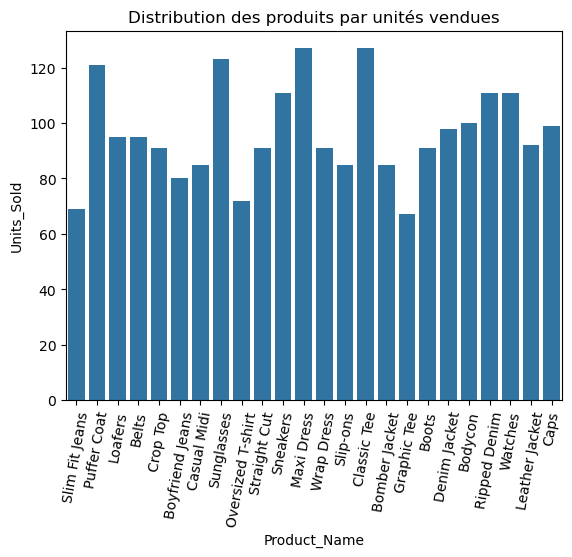

In [7]:
#Diagramme en barre
sn.barplot(data=data , x="Product_Name" , y="Units_Sold", estimator=sum , errorbar=None)
plt.title("Distribution des produits par unités vendues")
plt.xticks(rotation=80)
plt.show()

Par ce graphique , nous avons souhaité nous renseigner sur les 3 produits les plus vendus parmi les commandes passées auprès de l'entreprise. Nous pouvons remarquer que les 3 produits les plus vendus dans les commandes sont : Maxi Dress , Classic Tee et Sunglasses.

Nous avons utilisé un barplot car il est le graphique le plus souvent utilisé lorsque l'on souhaite comparé les valeurs d'une catégorie(variable) par rapport à une autre variable.


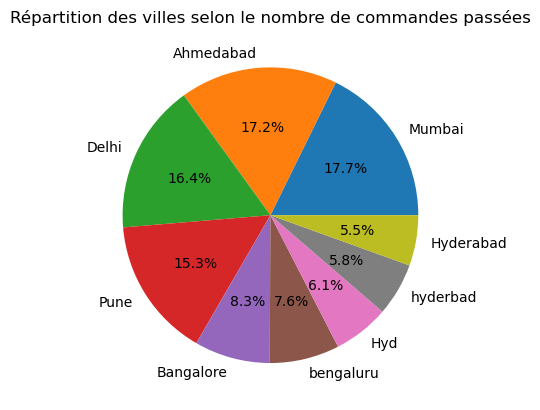

In [8]:
#Diagramme circulaire
comptage=data["City"].value_counts() 
plt.title ("Répartition des villes selon le nombre de commandes passées")
plt.pie(comptage, labels=comptage.index, autopct="%1.1f%%")
plt.show()

Par le biais  de ce graphique , nous avons souhaité voir sur quelle ville nos produits étaient le plus livrés.Avec des écarts très minces , nous avons 4 principales villes : Mumbai , Ahmedabad , Delhi et Pune.

Nous avons choisi un diagramme circulaire pour cette visualisation car il permet facilement de représenter comment les catégories d'une variable catégorielle sont représentées entre elles même.

PHASE 3 : NETTOYAGE ET PREPARATION

Pour la première partie de cette phase , nous allons procéder à la suppression des variables inutiles . Dans le modèle qui nous a été donné , les variables existantes à part la variable cible Profit sont : Units_Sold , Unit_Price , Discount_% , Segment , Product_Category , Sales_Amount et City . Les autres variables mis à part celles citées seront supprimées.

In [9]:
data_clean=data.drop(columns=["Order_ID","Customer_Name","Product_Name","Order_Date","Sales_Amount"])
data_clean.head(12)

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment,Profit
0,Jeans,NaN,842.00,0.60,Delhi,B2C,2137.45
1,Jeans,1.0,NaN,NaN,Ahmedabad,NaN,1588.15
2,Jackets,1.0,637.82,NaN,Mumbai,B2B,-158.03
3,Shoes,2.0,2962.27,NaN,bengaluru,B2B,2296.50
4,Accessories,1.0,2881.07,0.27,hyderbad,NaN,63.66
5,T-Shirts,NaN,NaN,NaN,Mumbai,B2B,1477.73
6,Jeans,1.0,2060.85,NaN,Ahmedabad,B2B,198.36
7,Dresses,NaN,3669.56,NaN,Bangalore,B2C,2490.01
8,Accessories,NaN,NaN,NaN,Ahmedabad,B2C,-886.80
9,T-Shirts,5.0,NaN,NaN,Bangalore,B2B,-972.73


Nous allons continuer notre travail par le traitement des valeurs manquantes.

In [10]:
data_clean.isnull().sum()

Product_Category       0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
City                   0
Segment              821
Profit                 0
dtype: int64

La colonne Segment ici a 821 données manquantes , nous aurions pu remplacer ces dernières par le mode de la distribution qui aurait été soit B2C ou B2B mais le faire ainsi pourrait fausser les statistiques.En y réfléchissant bien , il se pourrait que ceux qui ont commandé n'ont pas voulu indiqué leur entreprise ou tout simplement que la commande ait été faite par un particulier , alors au lieu de remplacer par le mode , nous allons tout simplement créer une 3e valeur pour segment qui sera "Autre". Cette dernière regroupera les différentes possibilités que nous pouvous avoir pour les valeurs manquantes de cette colonne.

In [11]:
data_clean["Segment"]=data_clean["Segment"].fillna("Autre")

In [12]:
data_clean.head(12)

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment,Profit
0,Jeans,NaN,842.00,0.60,Delhi,B2C,2137.45
1,Jeans,1.0,NaN,NaN,Ahmedabad,Autre,1588.15
2,Jackets,1.0,637.82,NaN,Mumbai,B2B,-158.03
3,Shoes,2.0,2962.27,NaN,bengaluru,B2B,2296.50
4,Accessories,1.0,2881.07,0.27,hyderbad,Autre,63.66
5,T-Shirts,NaN,NaN,NaN,Mumbai,B2B,1477.73
6,Jeans,1.0,2060.85,NaN,Ahmedabad,B2B,198.36
7,Dresses,NaN,3669.56,NaN,Bangalore,B2C,2490.01
8,Accessories,NaN,NaN,NaN,Ahmedabad,B2C,-886.80
9,T-Shirts,5.0,NaN,NaN,Bangalore,B2B,-972.73


Nous pouvous voir que le changement a été fait au sein de la colonne. Nous allons nous attaquer maintenant aux variables Units_Sold et Unit_Price. Pour savoir quoi faire , nous allons premièrement regarder leurs distributions respectives.

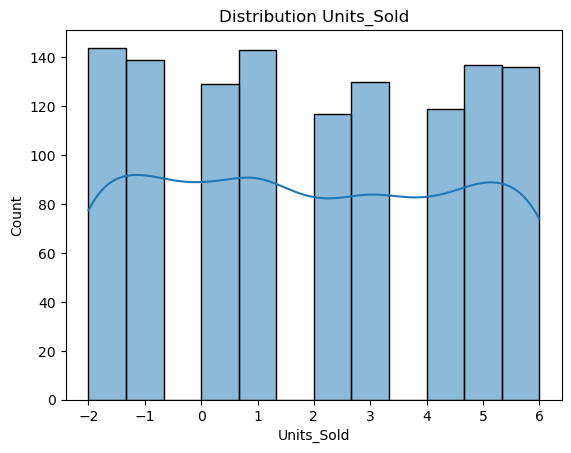

In [13]:
#Distribution Units_Sold
sn.histplot(data_clean["Units_Sold"], kde=True)
plt.title("Distribution Units_Sold")
plt.show()

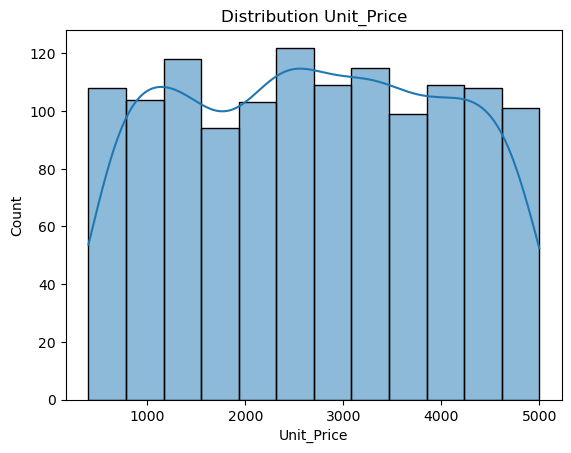

In [14]:
#Distribution Units_Sold
sn.histplot(data_clean["Unit_Price"], kde=True)
plt.title("Distribution Unit_Price")
plt.show()

Notre diagramme ne nous donne pas vraiment d'indication clair quant à la distribution , alors nous allons utiliser les statistiques des variables.

In [15]:
data_clean.describe()

,Units_Sold,Unit_Price,Discount_%,Profit
count,1194.000000,1290.000000,849.000000,2500.000000
mean,1.940536,2691.715527,0.646466,981.569032
std,2.625680,1320.448967,0.380331,1159.159244
min,-2.000000,400.210000,0.000000,-992.610000
25%,0.000000,1526.195000,0.300000,-19.670000
50%,2.000000,2685.985000,0.650000,947.885000
75%,4.000000,3824.347500,0.980000,1993.515000
max,6.000000,4998.910000,1.300000,2997.110000


In [16]:
print("Le skewness de Units_Sold est :", data_clean["Units_Sold"].skew())
print("Le skewness de Unit_Price est :", data_clean["Unit_Price"].skew())
print("---------------------------------------------------------")
print("Le kurtosis de Units_Sold est :", data_clean["Units_Sold"].kurtosis())
print("Le kurtosis de Unit_Price est :", data_clean["Unit_Price"].kurtosis())

Le skewness de Units_Sold est : 0.03750024939920212
Le skewness de Unit_Price est : 0.000379864445391768
---------------------------------------------------------
Le kurtosis de Units_Sold est : -1.2653235400507081
Le kurtosis de Unit_Price est : -1.1744176279632732


Nous pouvons voir grâce aux statistiques que Units_Sold et Unit_Price sont légèrement asymétrique vers la gauche et que leur distribution est applatie. Vu que nous ne sommes pas en présence de valeurs qui tirent excessivement la moyenne vers la droite alors nous allons l'utiliser pour remplacer les valeurs manquantes dans Units_Sold et Unit_Price. Nous utilisons la moyenne car pour une commande de produit , il n'est pas logique que la quantité est été oubliée ou qu'elle soit égale à 0 , tout comme le prix du produit.

In [17]:
data_clean.dtypes

Product_Category     object
Units_Sold          float64
Unit_Price          float64
Discount_%          float64
City                 object
Segment              object
Profit              float64
dtype: object

Après notre première imputation de données , Units_Sold et Unit_Price qui était des valeurs numeriques sont devenues des valeurs catégorielles. Nous allons changer leurs types , avant de passer à l'imputation des valeurs manquantes.

In [18]:
data_clean["Unit_Price"]=pd.to_numeric(data_clean["Unit_Price"], errors="coerce")
data_clean["Units_Sold"]=pd.to_numeric(data_clean["Units_Sold"], errors="coerce")

In [19]:
data_clean["Unit_Price"]=data_clean["Unit_Price"].fillna(data_clean["Unit_Price"].mean())
data_clean["Units_Sold"]=data_clean["Units_Sold"].fillna(data_clean["Units_Sold"].mean())


In [20]:
data_clean

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment,Profit
0,Jeans,1.940536,842.000000,0.60,Delhi,B2C,2137.45
1,Jeans,1.000000,2691.715527,NaN,Ahmedabad,Autre,1588.15
2,Jackets,1.000000,637.820000,NaN,Mumbai,B2B,-158.03
3,Shoes,2.000000,2962.270000,NaN,bengaluru,B2B,2296.50
4,Accessories,1.000000,2881.070000,0.27,hyderbad,Autre,63.66
...,...,...,...,...,...,...,...
2495,T-Shirts,1.940536,848.790000,NaN,Mumbai,Autre,2259.00
2496,Shoes,4.000000,2691.715527,NaN,Hyderabad,B2B,2232.98
2497,Jackets,1.940536,3389.240000,1.06,Ahmedabad,B2C,1955.31
2498,Jeans,5.000000,3844.190000,NaN,Hyd,Autre,2967.00


In [21]:
data_clean.isnull().sum()

Product_Category       0
Units_Sold             0
Unit_Price             0
Discount_%          1651
City                   0
Segment                0
Profit                 0
dtype: int64

Il ne reste que le variable Discount_% . Pour cette variable nous aurions pu tout simplement supprimer les valeurs maquantes mais après réflexion ces valeurs manquantes ne sont pas un problème. La présence de valeur manquante dans notre colonne , signifie tout simplement qu'il n y a pas eu de remise donc que les valeurs manquantes ici sont égales à 0. Nous allons alors changer ces valeurs par 0 au sein de notre colonne.

In [22]:
data_clean["Discount_%"]=data_clean["Discount_%"].fillna(0)

In [23]:
data_clean.isnull().sum()

Product_Category    0
Units_Sold          0
Unit_Price          0
Discount_%          0
City                0
Segment             0
Profit              0
dtype: int64

Comme nous pouvons le voir , les données manquantes ont été corrigées et il n y en a plus aucune.

Nous allons ensuite passer à l'encodage des variables catégorielles : City , Segment , Product_category

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
label_encoder=LabelEncoder()

In [26]:
data_clean["City"]=label_encoder.fit_transform(data_clean["City"])
data_clean["Segment"]=label_encoder.fit_transform(data_clean["Segment"])
data_clean["Product_Category"]=label_encoder.fit_transform(data_clean["Product_Category"])

In [27]:
data_clean

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment,Profit
0,3,1.940536,842.000000,0.60,2,2,2137.45
1,3,1.000000,2691.715527,0.00,0,0,1588.15
2,2,1.000000,637.820000,0.00,5,1,-158.03
3,4,2.000000,2962.270000,0.00,7,1,2296.50
4,0,1.000000,2881.070000,0.27,8,0,63.66
...,...,...,...,...,...,...,...
2495,5,1.940536,848.790000,0.00,5,0,2259.00
2496,4,4.000000,2691.715527,0.00,4,1,2232.98
2497,2,1.940536,3389.240000,1.06,0,2,1955.31
2498,3,5.000000,3844.190000,0.00,3,0,2967.00


In [28]:
data_clean.corr()

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment,Profit
Product_Category,1.000000,-0.012357,-0.013005,-0.006153,0.011850,-0.025558,-0.017983
Units_Sold,-0.012357,1.000000,-0.011329,0.005701,-0.009624,0.017648,-0.000125
Unit_Price,-0.013005,-0.011329,1.000000,0.002832,-0.018743,-0.052153,0.006914
Discount_%,-0.006153,0.005701,0.002832,1.000000,-0.002370,-0.037489,0.010081
City,0.011850,-0.009624,-0.018743,-0.002370,1.000000,-0.026000,0.040185
Segment,-0.025558,0.017648,-0.052153,-0.037489,-0.026000,1.000000,0.013534
Profit,-0.017983,-0.000125,0.006914,0.010081,0.040185,0.013534,1.000000


Nous allons maintenant vérifier la présence de doublons dans notre dataset

In [29]:
nombre=data_clean.duplicated().sum()

In [30]:
print("Il y a", nombre , "doublons dans notre dataset")

Il y a 0 doublons dans notre dataset


Nous allons nous attaquer maintenant aux valeurs manquantes.

Nous allons visualiser les outliers des variables Unit_Price , Units_Sold , Discount_% et Profit , pour le faire nous allons utiliser des boxplots.

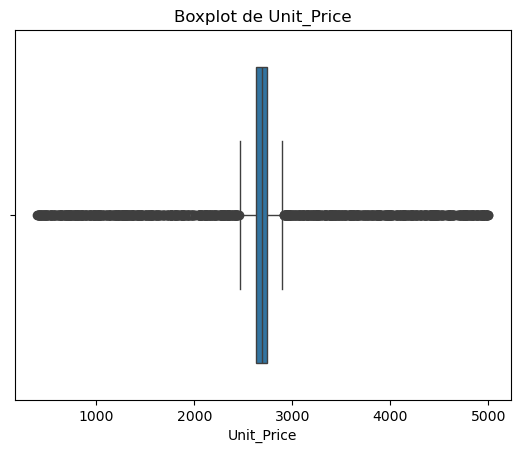

In [31]:
#boxplot Unit_Price
sn.boxplot(x=data_clean["Unit_Price"])
plt.title("Boxplot de Unit_Price")
plt.show()

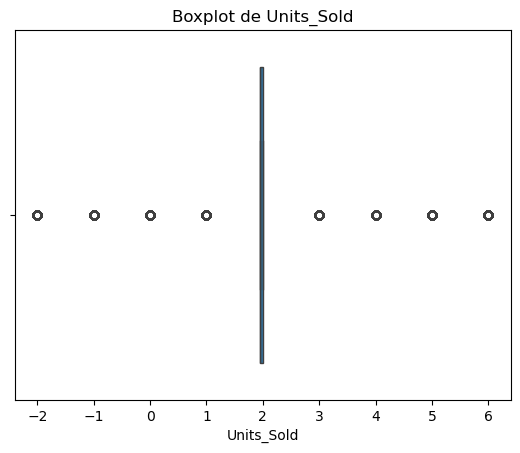

In [32]:
#boxplot Units_Sold
sn.boxplot(x=data_clean["Units_Sold"])
plt.title("Boxplot de Units_Sold")
plt.show()

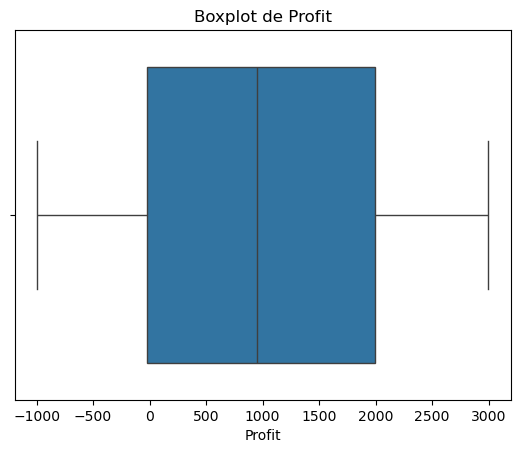

In [33]:
#boxplot Sales_Amount
sn.boxplot(x=data_clean["Profit"])
plt.title("Boxplot de Profit")
plt.show()

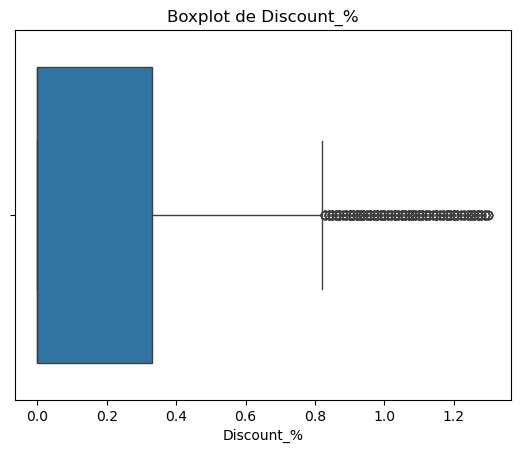

In [34]:
#boxplot Discount_%
sn.boxplot(x=data_clean["Discount_%"])
plt.title("Boxplot de Discount_%")
plt.show()

Après avoir regarder les boxplot et selon le contexte , une grande valeur positive ne représente pas un réel problème car nous pouvons avoir une grande quantité commandé , un taux de remise positif, un pofit élevé et donc un profit potentiellement élevé. Nous allons laissé la variable Unit_Price mais nous allons traiter Units_Sold car nous avons remarqué des unités vendues négatifs et il est impossible d'en avoir alors nous allons les supprimer.

In [35]:
#Nettoyage de Unit_Price
data_clean=data_clean[data_clean["Units_Sold"] > 0] 

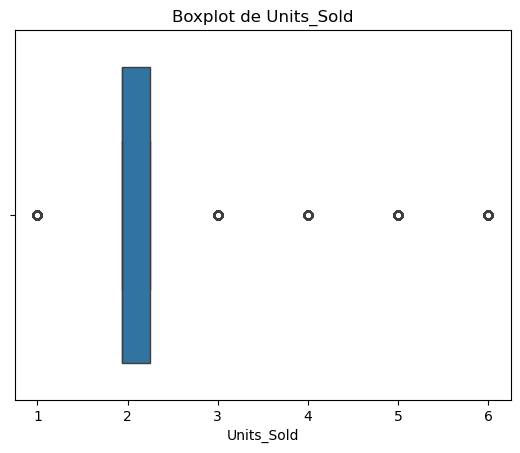

In [36]:
#boxplot Units_Sold
sn.boxplot(x=data_clean["Units_Sold"])
plt.title("Boxplot de Units_Sold")
plt.show()

Comme nous pouvons le voir sur le boxplot , les valeurs inférieures à 0 ont été supprimées pour Units_Sold , nous avons officiellement fini le nettoyage de nos données.

PHASE 4 : NORMALISATION ET SEPARATION

Nous allons procéder premièrement à la séparation des features.

In [37]:
X= data_clean.drop(columns=["Profit"])
Y=data_clean["Profit"]

In [38]:
Y

0       2137.45
1       1588.15
2       -158.03
3       2296.50
4         63.66
         ...   
2495    2259.00
2496    2232.98
2497    1955.31
2498    2967.00
2499     715.15
Name: Profit, Length: 2088, dtype: float64

In [39]:
X

,Product_Category,Units_Sold,Unit_Price,Discount_%,City,Segment
0,3,1.940536,842.000000,0.60,2,2
1,3,1.000000,2691.715527,0.00,0,0
2,2,1.000000,637.820000,0.00,5,1
3,4,2.000000,2962.270000,0.00,7,1
4,0,1.000000,2881.070000,0.27,8,0
...,...,...,...,...,...,...
2495,5,1.940536,848.790000,0.00,5,0
2496,4,4.000000,2691.715527,0.00,4,1
2497,2,1.940536,3389.240000,1.06,0,2
2498,3,5.000000,3844.190000,0.00,3,0


Nous allons ensuite diviser en données d'entraînement(train) et données de test(test)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train , X_test , y_train , y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

PHASE 5 : MODELISATION ET EVALUATION

Dans le cas de notre étude , nous devons prédire la variable Profit qui est une variable numérique ; dans ce cas nous utiliserons un modèle de modélisation conçus pour la modélisation des variables numériques : les modèles de régression.

Nous allons entraîner notre prédiction grâce à deux modèles pour une plus grande précision : la régression linéaire et le random forest regression.

Nous pensons d'abord à importer les métriques d'évaluation pour ne plus avoir à les importer pour chaque modèle.

In [42]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

- Régression linéaire

In [43]:

from sklearn.linear_model import LinearRegression

In [44]:
model1=LinearRegression()

In [45]:
model1.fit(X_train,y_train)

LinearRegression()

In [46]:
y_pred1=model1.predict(X_test)

In [47]:
print ("Le MAE de ce modèle est :" , mean_absolute_error(y_test,y_pred1))
print ("Le RMSE de ce modèle est :" , mean_squared_error(y_test,y_pred1))
print ("Le R2 de ce modèle est :" , r2_score(y_test,y_pred1))

Le MAE de ce modèle est : 972.9572077085056
Le RMSE de ce modèle est : 1318083.1720990515
Le R2 de ce modèle est : -0.014119936412751777


D'après les métriques calculées , le model de régression linéaire est très mauvais 

- Random Forest Regression

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
model2=RandomForestRegressor()

In [50]:
model2.fit(X_train , y_train)

RandomForestRegressor()

In [52]:
y_pred2=model2.predict(X_test)

In [ ]:
print ("Le MAE de ce modèle est :" , mean_absolute_error(y_test,y_pred2))
print ("Le RMSE de ce modèle est :" , mean_squared_error(y_test,y_pred2))
print ("Le R2 de ce modèle est :" , r2_score(y_test,y_pred2))

Le MAE de ce modèle est : 1051.0935667735955
Le RMSE de ce modèle est : 1565100.097040644
Le R2 de ce modèle est : -0.20417227416903416


Les deux modèles (y_pred1 et y_pred2) sont tous les deux de très modèles car leurs métriques sont mauvaises.

-Pour qu'un modèle soit assez correct , nous devons avoir au moins un R2 supérieur à 0 mais pour nos deux modèles , nos R2 sont négatifs , ce qui signifie que les deux modèles sont à rejeter!!

-Pour les deux modèles on a un RMSE qui est très élevé ce qui est indicateur d'un mauvais modèle car nous savons que plus petit un RMSE est , meilleur un modèle est.

-Le MAE aussi traduit l'écart entre les valeurs réelles et les valeurs prédites  les deux MAE observées pour nos modèles sont très grands ce qui met en lumière une énorme différence dans les prédictions.

Après avoir mieux observé nos données , nous avons compris que les modèles n'étaient pas bons car les variables explicatives , n'expliquaient pas bien le modèle : aucune n'a une bonne corrélation avec la variable Profit.

Le modèle avec les métriques les plus faibles est la Régression linéaire alors on le choisira.

PHASE 6 : DEPLOIEMENT INTERFACE GRADIO

Pour utiliser notre modèle dans notre fichier app.py d'interface Gradio , nous allons stocker le model grâce à la bibliothèque joblib.

In [54]:
import joblib

In [55]:
joblib.dump(model1 , "modele_choisi")
print("Notre modèle a été stocké")

Notre modèle a été stocké
